# Comparaison XGBoost vs Random Forest
## Prédiction de ventes avec méthode récursive

**Objectif**: Comparer les performances de XGBoost et Random Forest pour la prédiction de séries temporelles de ventes.

**Méthodologie**: 
- Utilisation d'une approche récursive où les prédictions d'un pas de temps servent de features pour le pas suivant
- Split temporel: Train / Validation / Test
- Encodages optimisés pour les variables catégorielles
- Exclusion des variables oil_price pour éviter le data leakage

## Table des matières

1. [Configuration de l'environnement](#1-configuration)
2. [Chargement des données](#2-donnees)
3. [Fonctions de modélisation](#3-fonctions)
4. [Configuration des hyperparamètres](#4-hyperparametres)
5. [Entraînement et prédictions](#5-entrainement)
6. [Évaluation des performances](#6-evaluation)
7. [Visualisations comparatives](#7-visualisations)

## 1. Configuration de l'environnement <a id='1-configuration'></a>

Cette section initialise l'environnement de travail et importe les bibliothèques nécessaires.

In [1]:
# Changement du répertoire de travail pour accéder aux modules du projet
import os 
os.chdir("..")

In [2]:
# Imports standards
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostRegressor
# Modèles de machine learning
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
# Modules personnalisés du projet
from src.feature_engineering import (
    apply_catboost_encoding, 
    apply_robust_scaler, 
    apply_target_encoding, 
    apply_label_encoding_nn
)
from src.evaluation import evaluate_model

# Analyse des features
import shap

## 2. Chargement des données <a id='2-donnees'></a>

Les données sont stockées au format Parquet pour optimiser les performances de lecture.
- **train_sales_data.parquet**: Données d'entraînement historiques
- **test_sales_data.parquet**: Données de test pour les prédictions futures

In [3]:
# Chargement des datasets
train = pd.read_parquet('data/train_sales_data.parquet')
test = pd.read_parquet('data/test_sales_data.parquet')

# Affichage des dimensions
print(f"Données d'entraînement: {train.shape}")
print(f"Données de test: {test.shape}")

Données d'entraînement: (2901096, 44)
Données de test: (99792, 44)


In [4]:
def compute_catboost_encoding_at_date(historical_df, current_df, cols, target, alpha=None):
    """
    Calcule l'encodage CatBoost pour current_df en utilisant UNIQUEMENT historical_df.
    
    Parameters
    ----------
    historical_df : pd.DataFrame
        Données historiques (train + prédictions précédentes)
    current_df : pd.DataFrame  
        Données du jour actuel à encoder
    cols : list
        Colonnes catégorielles à encoder
    target : str
        Nom de la colonne cible
    alpha : float, optional
        Paramètre de smoothing
        
    Returns
    -------
    pd.DataFrame
        current_df avec colonnes catboost_enc_* ajoutées
    """
    
    current_encoded = current_df.copy()
    global_mean = historical_df[target].mean()
    
    for col in cols:
        # Calcul dynamique de alpha
        if alpha is None:
            n_categories = historical_df[col].nunique()
            current_alpha = np.log1p(n_categories) * 5
        else:
            current_alpha = alpha
        
        # Calculer les statistiques sur l'historique
        group_stats = historical_df.groupby(col)[target].agg(['sum', 'count'])
        
        # Formule CatBoost
        encoding_map = (
            (group_stats['sum'] + current_alpha * global_mean) / 
            (group_stats['count'] + current_alpha)
        ).to_dict()
        
        # Appliquer l'encodage
        col_name = f'catboost_enc_{col}'
        current_encoded[col_name] = current_encoded[col].map(encoding_map).fillna(global_mean)
    
    return current_encoded

## 3. Fonctions de modélisation <a id='3-fonctions'></a>

Cette section définit les fonctions principales pour l'entraînement et l'évaluation des modèles.

### 3.1 Fonction XGBoost avec prédiction récursive

**Principe de la prédiction récursive**:
1. On prédit le premier jour de test avec les vraies valeurs d'entraînement
2. Cette prédiction devient une feature pour prédire le jour suivant
3. On répète le processus pour chaque jour de la période de test

**Optimisations clés**:
- Les encodages sont calculés une seule fois sur le train complet
- Les prédictions sont clippées à 0 (pas de ventes négatives)
- Exclusion des variables oil_price pour éviter le data leakage

In [5]:
def process_single_day_xgb(current_date, combined_data, catboost_cols, target, features, 
                           original_cols_that_were_scaled, scaler, model):
    """
    Traite un seul jour de prédiction pour XGBoost (fonction optimisée).
    
    Returns
    -------
    tuple
        (day_results_df, y_pred_day, day_indices)
    """
    
    # ====================================================================
    # ÉTAPE 1: RECALCULER ENCODAGES CATBOOST
    # ====================================================================
    
    historical_mask = combined_data['date'] < current_date
    historical_data = combined_data[historical_mask]
    global_mean = historical_data[target].mean()
    
    catboost_encodings = {}
    for cat_col in catboost_cols:
        n_categories = historical_data[cat_col].nunique()
        alpha = np.log1p(n_categories) * 5
        
        group_stats = historical_data.groupby(cat_col)[target].agg(['sum', 'count'])
        catboost_encodings[cat_col] = (
            (group_stats['sum'] + alpha * global_mean) / 
            (group_stats['count'] + alpha)
        ).to_dict()
    
    # Données du jour
    day_mask = (combined_data['date'] == current_date)
    day_data = combined_data[day_mask].copy()
    
    if len(day_data) == 0:
        return None, None, None
    
    # Appliquer encodages
    for cat_col in catboost_cols:
        col_name = f'catboost_enc_{cat_col}'
        encoded_series = day_data[cat_col].map(catboost_encodings[cat_col])
        encoded_values = encoded_series.values
        encoded_values = np.where(np.isnan(encoded_values), global_mean, encoded_values)
        day_data[col_name] = encoded_values
    
    # ====================================================================
    # ÉTAPE 2: METTRE À JOUR LES LAGS (VECTORISÉ)
    # ====================================================================
    
    for lag_days in [1, 2, 3, 7, 14, 28, 56]:
        lag_col = f'sales_lag_{lag_days}'
        if lag_col not in day_data.columns:
            continue
        
        lag_date = current_date - pd.Timedelta(days=lag_days)
        
        # Vectorisé: récupérer toutes les valeurs en une fois
        lag_values = combined_data[combined_data['date'] == lag_date][
            ['store_nbr', 'family', target]
        ].rename(columns={target: f'{lag_col}_temp'})
        
        day_data = day_data.merge(lag_values, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{lag_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, lag_col] = day_data.loc[mask, f'{lag_col}_temp']
        day_data.drop(columns=[f'{lag_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 3: METTRE À JOUR LES ROLLING MEANS (VECTORISÉ)
    # ====================================================================
    
    for window in [7, 14, 28]:
        rolling_col = f'rolling_mean_{window}'
        if rolling_col not in day_data.columns:
            continue
        
        start_date = current_date - pd.Timedelta(days=window)
        
        # Vectorisé: calculer toutes les rolling means en une fois
        rolling_window_data = combined_data[
            (combined_data['date'] >= start_date) & 
            (combined_data['date'] < current_date)
        ]
        
        rolling_means = rolling_window_data.groupby(['store_nbr', 'family'])[target].mean().reset_index()
        rolling_means = rolling_means.rename(columns={target: f'{rolling_col}_temp'})
        
        day_data = day_data.merge(rolling_means, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{rolling_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, rolling_col] = day_data.loc[mask, f'{rolling_col}_temp']
        day_data.drop(columns=[f'{rolling_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 4: APPLIQUER LE SCALER
    # ====================================================================
    
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in day_data.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(day_data[cols_to_scale])
        for i, col_name in enumerate(cols_to_scale):
            scaled_col_name = f'scaled_{col_name}'
            if scaled_col_name in features:
                day_data[scaled_col_name] = scaled_values[:, i]
    
    # ====================================================================
    # ÉTAPE 5: PRÉDICTION
    # ====================================================================
    
    X_day = day_data[features]
    y_pred_day = model.predict(X_day)
    y_pred_day = np.maximum(y_pred_day, 0)
    
    # Résultat
    day_indices = combined_data[day_mask].index
    day_results = pd.DataFrame({
        'date': combined_data.loc[day_indices, 'date'].values,
        'store_nbr': combined_data.loc[day_indices, 'store_nbr'].values,
        'family': combined_data.loc[day_indices, 'family'].values,
        'y_pred': y_pred_day
    })
    
    return day_results, y_pred_day, day_indices


def train_and_evaluate_split_recursive_optimized(train_df, test_df, split_config, use_gpu=False, hyperparams=None):
    """
    Prédiction récursive XGBoost OPTIMISÉE et SANS LEAKAGE.
    
    IMPORTANT: 
    - Variables oil_price exclues pour éviter le data leakage
    - Encodages CatBoost recalculés dynamiquement à chaque jour
    - Lags et rolling means vectorisés pour performance
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split avec clés:
        - 'name': nom du split
        - 'use_real_test': True pour utiliser test_df, False pour split sur train_df
        - 'train_end': date de fin du train (si use_real_test=False)
        - 'test_start': date de début du test (si use_real_test=False)
        - 'test_end': date de fin du test (si use_real_test=False)
    use_gpu : bool
        Utiliser le GPU pour XGBoost
    hyperparams : dict, optional
        Dictionnaire des hyperparamètres XGBoost
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    # Hyperparamètres par défaut
    if hyperparams is None:
        hyperparams = {'n_estimators': 125,
            'max_depth': 12,
            'learning_rate': 0.07937357644840533,
            'reg_alpha': 0.0165275816937389,
            'reg_lambda': 1.3680710018317017e-08,
            'subsample': 0.5167929424672361,
            'colsample_bytree': 0.7818042890078679,
            'colsample_bylevel': 0.9980082658737177,
            'min_child_weight': 8,
            'gamma': 0.005253538564644457}
    
    # Creation des ensembles train et test
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    print(f"GPU:   {'Activé' if use_gpu else 'Désactivé'}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE (encodage sur train uniquement)
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    train_processed = apply_catboost_encoding(
        train_split,
        cols=catboost_cols,
        target=target,
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    # Definition des features
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
        'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    # Identifier les colonnes scalées
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    
    X_train = train_scaled[features]
    y_train = train_scaled[target]
    
    print(f"Nombre de features: {len(features)}")
    print(f"  Variables oil_price EXCLUES (éviter data leakage)")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT XGBOOST
    # ========================================================================
    
    print(f"\n[2/4] Entrainement XGBoost {'sur GPU' if use_gpu else 'sur CPU'}...")
    print(f"Hyperparams: max_depth={hyperparams['max_depth']}, lr={hyperparams['learning_rate']}, n_est={hyperparams['n_estimators']}")
    
    if use_gpu:
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=hyperparams['max_depth'],
            learning_rate=hyperparams['learning_rate'],
            n_estimators=hyperparams['n_estimators'],
            subsample=hyperparams['subsample'],
            colsample_bytree=hyperparams['colsample_bytree'],
            min_child_weight=hyperparams['min_child_weight'],
            random_state=42,
            tree_method='hist',
            device='cuda',
            n_jobs=1
        )
    else:
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            max_depth=hyperparams['max_depth'],
            learning_rate=hyperparams['learning_rate'],
            n_estimators=hyperparams['n_estimators'],
            subsample=hyperparams['subsample'],
            colsample_bytree=hyperparams['colsample_bytree'],
            min_child_weight=hyperparams['min_child_weight'],
            random_state=42,
            tree_method='hist',
            device='cpu',
            n_jobs=-1
        )
    
    model.fit(X_train, y_train, verbose=False)
    print("Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION POUR PREDICTION RECURSIVE
    # ========================================================================
    
    print("\n[3/4] Préparation pour prédiction récursive...")
    
    # Combiner train et test SANS encodage CatBoost préalable
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Convertir colonnes catégorielles en object
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    print("Données préparées (tri effectué)")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE OPTIMISÉE
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    print(f"\n[4/4] Prédiction récursive OPTIMISÉE sur {len(test_dates)} jours...")
    
    predictions_list = []
    n_clipped = 0
    
    for day_idx, current_date in enumerate(test_dates):
        
        result = process_single_day_xgb(
            current_date, combined_data, catboost_cols, target, features,
            original_cols_that_were_scaled, scaler, model
        )
        
        if result[0] is None:
            continue
        
        day_results, y_pred_day, day_indices = result
        
        # Mise à jour pour récursivité
        combined_data.loc[day_indices, target] = y_pred_day
        
        n_clipped += (y_pred_day < 0).sum()
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0 or day_idx == 0:
            print(f"  {day_idx + 1}/{len(test_dates)} jours traités")
    
    if n_clipped > 0:
        print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n  Aucune prédiction négative")
    
    # ========================================================================
    # CONSOLIDATION ET ÉVALUATION
    # ========================================================================
    
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'use_gpu': use_gpu,
        'n_clipped': n_clipped,
        'hyperparams': hyperparams
    }
    
    return results

### 3.2 Fonction Random Forest avec prédiction récursive

Implémentation similaire à XGBoost mais utilisant Random Forest comme modèle de base.
Les mêmes principes d'optimisation et de prédiction récursive s'appliquent.

In [6]:
from joblib import Parallel, delayed
import multiprocessing

def process_single_day_rf(current_date, combined_data, catboost_cols, target, features, 
                       original_cols_that_were_scaled, scaler, model):
    """
    Traite un seul jour de prédiction (fonction pour parallélisation).
    
    Returns
    -------
    tuple
        (day_results_df, y_pred_day, day_indices)
    """
    
    # ====================================================================
    # ÉTAPE 1: RECALCULER ENCODAGES CATBOOST
    # ====================================================================
    
    historical_mask = combined_data['date'] < current_date
    historical_data = combined_data[historical_mask]
    global_mean = historical_data[target].mean()
    
    catboost_encodings = {}
    for cat_col in catboost_cols:
        n_categories = historical_data[cat_col].nunique()
        alpha = np.log1p(n_categories) * 5
        
        group_stats = historical_data.groupby(cat_col)[target].agg(['sum', 'count'])
        catboost_encodings[cat_col] = (
            (group_stats['sum'] + alpha * global_mean) / 
            (group_stats['count'] + alpha)
        ).to_dict()
    
    # Données du jour
    day_mask = (combined_data['date'] == current_date)
    day_data = combined_data[day_mask].copy()
    
    if len(day_data) == 0:
        return None, None, None
    
    # Appliquer encodages
    for cat_col in catboost_cols:
        col_name = f'catboost_enc_{cat_col}'
        encoded_series = day_data[cat_col].map(catboost_encodings[cat_col])
        encoded_values = encoded_series.values
        encoded_values = np.where(np.isnan(encoded_values), global_mean, encoded_values)
        day_data[col_name] = encoded_values
    
    # ====================================================================
    # ÉTAPE 2: METTRE À JOUR LES LAGS (VECTORISÉ)
    # ====================================================================
    
    for lag_days in [1, 2, 3, 7, 14, 28, 56]:
        lag_col = f'sales_lag_{lag_days}'
        if lag_col not in day_data.columns:
            continue
        
        lag_date = current_date - pd.Timedelta(days=lag_days)
        
        # Vectorisé: récupérer toutes les valeurs en une fois
        lag_values = combined_data[combined_data['date'] == lag_date][
            ['store_nbr', 'family', target]
        ].rename(columns={target: f'{lag_col}_temp'})
        
        day_data = day_data.merge(lag_values, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{lag_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, lag_col] = day_data.loc[mask, f'{lag_col}_temp']
        day_data.drop(columns=[f'{lag_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 3: METTRE À JOUR LES ROLLING MEANS (VECTORISÉ)
    # ====================================================================
    
    for window in [7, 14, 28]:
        rolling_col = f'rolling_mean_{window}'
        if rolling_col not in day_data.columns:
            continue
        
        start_date = current_date - pd.Timedelta(days=window)
        
        # Vectorisé: calculer toutes les rolling means en une fois
        rolling_window_data = combined_data[
            (combined_data['date'] >= start_date) & 
            (combined_data['date'] < current_date)
        ]
        
        rolling_means = rolling_window_data.groupby(['store_nbr', 'family'])[target].mean().reset_index()
        rolling_means = rolling_means.rename(columns={target: f'{rolling_col}_temp'})
        
        day_data = day_data.merge(rolling_means, on=['store_nbr', 'family'], how='left')
        
        mask = day_data[f'{rolling_col}_temp'].notna()
        if mask.sum() > 0:
            day_data.loc[mask, rolling_col] = day_data.loc[mask, f'{rolling_col}_temp']
        day_data.drop(columns=[f'{rolling_col}_temp'], inplace=True)
    
    # ====================================================================
    # ÉTAPE 4: APPLIQUER LE SCALER
    # ====================================================================
    
    cols_to_scale = [c for c in original_cols_that_were_scaled if c in day_data.columns]
    
    if len(cols_to_scale) > 0:
        scaled_values = scaler.transform(day_data[cols_to_scale])
        for i, col_name in enumerate(cols_to_scale):
            scaled_col_name = f'scaled_{col_name}'
            if scaled_col_name in features:
                day_data[scaled_col_name] = scaled_values[:, i]
    
    # ====================================================================
    # ÉTAPE 5: PRÉDICTION
    # ====================================================================
    
    X_day = day_data[features]
    y_pred_day = model.predict(X_day)
    y_pred_day = np.maximum(y_pred_day, 0)
    
    # Résultat
    day_indices = combined_data[day_mask].index
    day_results = pd.DataFrame({
        'date': combined_data.loc[day_indices, 'date'].values,
        'store_nbr': combined_data.loc[day_indices, 'store_nbr'].values,
        'family': combined_data.loc[day_indices, 'family'].values,
        'y_pred': y_pred_day
    })
    
    return day_results, y_pred_day, day_indices


def train_and_evaluate_split_rf_recursive(train_df, test_df, split_config, hyperparams=None, n_jobs=-1):
    """
    Prédiction récursive Random Forest PARALLÉLISÉE et OPTIMISÉE.
    
    IMPORTANT:
    - Variables oil_price exclues pour éviter le data leakage
    - Encodages CatBoost recalculés dynamiquement à chaque jour
    - Parallélisation des jours pour accélérer le calcul
    
    Parameters
    ----------
    train_df : pd.DataFrame
        Dataframe d'entrainement complet
    test_df : pd.DataFrame
        Dataframe de test final
    split_config : dict
        Configuration du split
    hyperparams : dict, optional
        Hyperparametres Random Forest personnalises
    n_jobs : int, default=-1
        Nombre de CPU à utiliser (-1 = tous)
    
    Returns
    -------
    dict
        Dictionnaire contenant les resultats, metriques et predictions
    """
    
    warnings.filterwarnings('ignore')
    
    # ========================================================================
    # CONFIGURATION
    # ========================================================================
    
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    
    # ========================================================================
    # PHASE 1: PREPARATION INITIALE
    # ========================================================================
    
    print("\n[1/4] Feature engineering sur train...")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    train_processed = apply_catboost_encoding(
        train_split,
        cols=catboost_cols,
        target=target,
        nb_previous_days_to_ignore=56,
        fill_first_na=True
    )
    
    train_scaled, scaler = apply_robust_scaler(
        train_processed,
        exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                      'store_type', 'cluster', 'sales', 'log_sales',
                      'is_holiday_local', 'is_holiday_regional', 
                      'is_holiday_national', 'is_store_closed', 
                      'is_weekend', 'is_payday', 'is_earthquake_impact',
                      'is_family_unactive', 'holiday_type'],
        drop_original=True
    )
    
    exclude_from_features = [
        'id', 'date', 'sales', 'log_sales',
        'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
        'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
    ]

    features = []
    for col in train_scaled.columns:
        if col in exclude_from_features:
            continue
        if train_scaled[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
            features.append(col)
    
    scaled_cols_in_train = [c for c in train_scaled.columns if c.startswith('scaled_')]
    original_cols_that_were_scaled = [c.replace('scaled_', '') for c in scaled_cols_in_train]
    
    X_train = train_scaled[features]
    y_train = train_scaled[target]
    
    print(f"Nombre de features: {len(features)}")
    print(f"  Variables oil_price EXCLUES (éviter data leakage)")
    
    # ========================================================================
    # PHASE 2: ENTRAINEMENT RANDOM FOREST
    # ========================================================================
    
    print(f"\n[2/4] Entrainement Random Forest...")
    
    if hyperparams is None:
        hyperparams = {
            'n_estimators': 175,
            'max_depth': 25,
            'min_samples_split': 10,
            'min_samples_leaf': 6,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    print(f"Hyperparams: n_est={hyperparams['n_estimators']}, max_depth={hyperparams['max_depth']}")
    
    model = RandomForestRegressor(**hyperparams)
    model.fit(X_train, y_train)
    print("Entraînement terminé")
    
    # ========================================================================
    # PHASE 3: PREPARATION POUR PREDICTION RECURSIVE
    # ========================================================================
    
    print("\n[3/4] Préparation pour prédiction récursive...")
    
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    # Convertir colonnes catégorielles
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    print("Données préparées (tri effectué)")
    
    # ========================================================================
    # PHASE 4: PREDICTION RECURSIVE PARALLÉLISÉE
    # ========================================================================
    
    test_dates = sorted(test_split['date'].unique())
    n_cpus = multiprocessing.cpu_count() if n_jobs == -1 else n_jobs
    
    print(f"\n[4/4] Prédiction récursive PARALLÉLISÉE sur {len(test_dates)} jours...")
    print(f"  Utilisation de {n_cpus} CPU")
    
    # ATTENTION: La parallélisation pure ne marche pas ici car chaque jour
    # dépend des prédictions précédentes (récursif)
    # On doit traiter séquentiellement mais optimiser chaque jour
    
    predictions_list = []
    n_clipped = 0
    
    for day_idx, current_date in enumerate(test_dates):
        
        result = process_single_day_rf(
            current_date, combined_data, catboost_cols, target, features,
            original_cols_that_were_scaled, scaler, model
        )
        
        if result[0] is None:
            continue
        
        day_results, y_pred_day, day_indices = result
        
        # Mise à jour pour récursivité
        combined_data.loc[day_indices, target] = y_pred_day
        
        n_clipped += (y_pred_day < 0).sum()
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0 or day_idx == 0:
            print(f"  {day_idx + 1}/{len(test_dates)} jours traités")
    
    if n_clipped > 0:
        print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    else:
        print(f"\n  Aucune prédiction négative")
    
    # ========================================================================
    # CONSOLIDATION ET ÉVALUATION
    # ========================================================================
    
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    print("\n[Evaluation] Calcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (RF Recursive)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'model': model,
        'features': features,
        'scaler': scaler,
        'predictions': all_predictions,
        'n_clipped': n_clipped,
        'hyperparams': hyperparams
    }
    
    return results

### 3.3 Modélisation directe via 4 modèles RF (7j, 14j, 28j, 56j)

Pour le 1-7 j on utilise la prédiction du modèle 7j, puis pour 7-14j celle du modèle 14j... 

In [ ]:
def train_and_evaluate_multi_direc_rf_clean(train_df, test_df, split_config, 
                                             horizons=[7, 14, 28, 56], hyperparams=None):
    """
    Multi-DiRec SANS lags shiftés : un modèle spécialisé pour chaque segment temporel.
    
    Strategy
    --------
    - Modèle H7  : prédit jours 1-7
    - Modèle H14 : prédit jours 8-14
    - Modèle H28 : prédit jours 15-28
    - Modèle H56 : prédit jours 29-56
    
    Utilise uniquement les 27 features de base (pas de lags shiftés)
    """
    
    warnings.filterwarnings('ignore')
    
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    print(f"Multi-DiRec CLEAN: {len(horizons)} modèles pour horizons {horizons}")
    print("SANS lags shiftés - 27 features de base uniquement")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    if hyperparams is None:
        hyperparams = {
            'n_estimators': 175,
            'max_depth': 25,
            'min_samples_split': 10,
            'min_samples_leaf': 6,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    models = {}
    scalers = {}
    features_dict = {}
    original_cols_dict = {}
    
    # ========================================================================
    # ENTRAINEMENT DES MODÈLES PAR HORIZON
    # ========================================================================
    
    for idx, horizon in enumerate(horizons):
        print(f"\n{'='*60}")
        print(f"[{idx+1}/{len(horizons)}] MODÈLE HORIZON {horizon}j")
        print(f"{'='*60}")
        
        # Dataset standard SANS lags shiftés
        train_h = train_split.copy()
        
        # Preprocessing
        train_processed_h = apply_catboost_encoding(
            train_h,
            cols=catboost_cols,
            target=target,
            nb_previous_days_to_ignore=56,
            fill_first_na=True
        )
        
        train_scaled_h, scaler_h = apply_robust_scaler(
            train_processed_h,
            exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                          'store_type', 'cluster', 'sales', 'log_sales',
                          'is_holiday_local', 'is_holiday_regional', 
                          'is_holiday_national', 'is_store_closed', 
                          'is_weekend', 'is_payday', 'is_earthquake_impact',
                          'is_family_unactive', 'holiday_type'],
            drop_original=True
        )
        
        # Features (27 features de base, SANS lags shiftés)
        exclude_from_features = [
            'id', 'date', 'sales', 'log_sales',
            'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
            'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
        ]
        
        features_h = []
        for col in train_scaled_h.columns:
            if col in exclude_from_features:
                continue
            if train_scaled_h[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
                features_h.append(col)
        
        X_train_h = train_scaled_h[features_h]
        y_train_h = train_scaled_h[target]
        
        scaled_cols_h = [c for c in train_scaled_h.columns if c.startswith('scaled_')]
        original_cols_h = [c.replace('scaled_', '') for c in scaled_cols_h]
        
        # Entraîner modèle
        print(f"Features: {len(features_h)} (sans lags shiftés)")
        model_h = RandomForestRegressor(**hyperparams)
        model_h.fit(X_train_h, y_train_h)
        print(f"Modèle H{horizon} entraîné")
        
        models[horizon] = model_h
        scalers[horizon] = scaler_h
        features_dict[horizon] = features_h
        original_cols_dict[horizon] = original_cols_h
    
    # ========================================================================
    # PRÉDICTION MULTI-HORIZON
    # ========================================================================
    
    print(f"\n{'='*60}")
    print("PRÉDICTION MULTI-HORIZON")
    print(f"{'='*60}")
    
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    test_dates = sorted(test_split['date'].unique())
    predictions_list = []
    n_clipped = 0
    
    # Définir les segments
    segments = []
    start_day = 0
    for horizon in horizons[:-1]:
        segments.append((start_day, horizon, horizon))
        start_day = horizon
    segments.append((start_day, len(test_dates), horizons[-1]))
    
    print(f"\nSegments définis:")
    for start, end, h in segments:
        print(f"  Jours {start+1}-{end}: Modèle H{h}")
    
    for day_idx, current_date in enumerate(test_dates):
        
        # Déterminer quel modèle utiliser
        model_to_use = None
        for start, end, h in segments:
            if start <= day_idx < end:
                model_to_use = h
                break
        
        if model_to_use is None:
            model_to_use = horizons[-1]
        
        # Prédiction avec le modèle approprié (fonction RF standard)
        result = process_single_day_rf(
            current_date, combined_data, catboost_cols, target, 
            features_dict[model_to_use],
            original_cols_dict[model_to_use], 
            scalers[model_to_use], 
            models[model_to_use]
        )
        
        if result[0] is None:
            continue
        
        day_results, y_pred_day, day_indices = result
        
        # Mise à jour récursive
        combined_data.loc[day_indices, target] = y_pred_day
        
        n_clipped += (y_pred_day < 0).sum()
        predictions_list.append(day_results)
        
        if (day_idx + 1) % 7 == 0 or day_idx == 0:
            print(f"  {day_idx + 1}/{len(test_dates)} jours (H{model_to_use})")
    
    print(f"\n  {n_clipped} prédictions négatives clippées à 0")
    
    # ========================================================================
    # CONSOLIDATION
    # ========================================================================
    
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    
    test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
    all_predictions = all_predictions.merge(
        test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
        on=['date', 'store_nbr', 'family'],
        how='left'
    )
    all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
    
    print("\nCalcul des métriques...")
    metrics = evaluate_model(
        y_true=all_predictions['y_true'].values,
        y_pred=all_predictions['y_pred'].values,
        is_store_closed=all_predictions['is_store_closed'].values,
        is_family_unactive=all_predictions['is_family_unactive'].values
    )
    
    results = {
        'split_name': split_config['name'] + ' (Multi-DiRec RF Clean)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': metrics,
        'models': models,
        'features_dict': features_dict,
        'scalers': scalers,
        'predictions': all_predictions,
        'n_clipped': n_clipped,
        'horizons': horizons,
        'hyperparams': hyperparams
    }
    
    return results

## 4. Configuration des plages d'entrainement, de validation, de test, et les hyperparamètres <a id='4-hyperparametres'></a>

Les hyperparamètres ont été déterminés, en faisant des itérations train / val, avec différents paramètres jusqu'à ce que les loss ne diminuent plus que très peu.

In [7]:
test_start_date = test['date'].min()
test_end_date = test['date'].max()
n_test_days = (test_end_date - test_start_date).days + 1

print(f"\n  Dates du fichier test.csv:")
print(f"  Test: {test_start_date.date()} → {test_end_date.date()} ({n_test_days} jours)")

# Récupérer toutes les dates du train
train_dates = sorted(train['date'].unique())
n_dates = len(train_dates)

# Validation: les 56 derniers jours du train (juste avant le test)
val_start_idx = n_dates - 56
val_start_date = train_dates[val_start_idx]
val_end_date = train_dates[-1]

# Train: tout ce qui est avant la validation
train_end_date = train_dates[val_start_idx - 1]

print(f"\n  Configuration du split avec fenêtres de 56 jours:")
print(f"="*80)
print(f"  Train:      {train_dates[0].date()} → {train_end_date.date()} ({val_start_idx} jours)")
print(f"  Validation: {val_start_date.date()} → {val_end_date.date()} (56 jours)")
print(f"  Test:       {test_start_date.date()} → {test_end_date.date()} ({n_test_days} jours) <- VRAI TEST.CSV")
print(f"="*80)

# Vérifications
print(f"\n  Validation: {(val_end_date - val_start_date).days + 1} jours")
print(f"  Test: {n_test_days} jours")
print(f"  Gap entre validation et test: {(test_start_date - val_end_date).days - 1} jour(s)")

# Créer les configurations pour chaque ensemble
VAL_CONFIG = {
    'name': 'Validation Set (56j)',
    'train_end': train_end_date,
    'test_start': val_start_date,
    'test_end': val_end_date,
    'use_real_test': False,
    'purpose': 'VALIDATION'
}

TEST_CONFIG = {
    'name': 'Test Set (VRAI test.csv)',
    'train_end': val_end_date,
    'test_start': test_start_date,
    'test_end': test_end_date,
    'use_real_test': True,
    'purpose': 'TEST'
}


  Dates du fichier test.csv:
  Test: 2017-06-21 → 2017-08-15 (56 jours)

  Configuration du split avec fenêtres de 56 jours:
  Train:      2013-01-01 → 2017-04-25 (1572 jours)
  Validation: 2017-04-26 → 2017-06-20 (56 jours)
  Test:       2017-06-21 → 2017-08-15 (56 jours) <- VRAI TEST.CSV

  Validation: 56 jours
  Test: 56 jours
  Gap entre validation et test: 0 jour(s)


## 5. Entraînement et prédictions <a id='5-entrainement'></a>

Entraînement des deux modèles et génération des prédictions.

### 5.1 Entraînement XGBoost

Cette étape peut prendre plusieurs minutes selon la taille des données.

In [8]:
print(f"\n{'='*80}")
print(f"XGBOOST - VALIDATION (56 JOURS)")
print(f"{'='*80}")

result_xgb_val = train_and_evaluate_split_recursive_optimized(
    train_df=train,
    test_df=test,
    split_config=VAL_CONFIG,
    use_gpu=True
)

if result_xgb_val is not None:
    print(f"\n  Résultats XGBoost (Validation - 56j):")
    print(f"  RMSLE: {result_xgb_val['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_xgb_val['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_xgb_val['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_xgb_val['n_clipped']}")



XGBOOST - VALIDATION (56 JOURS)
Train: 2013-01-01 00:00:00 -> 2017-04-25 00:00:00
Test:  2017-04-26 00:00:00 -> 2017-06-20 00:00:00
GPU:   Activé

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 348.8704833984375
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 348.8704833984375
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 348.8704833984375
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 348.8704833984375
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_price

In [9]:
# ========================================================================
# XGBOOST - TEST FINAL
# ========================================================================
print(f"\n{'='*80}")
print(f"XGBOOST - TEST FINAL (VRAI TEST.CSV - {n_test_days}J)")
print(f"{'='*80}")

result_xgb_test = train_and_evaluate_split_recursive_optimized(
    train_df=train,
    test_df=test,
    split_config=TEST_CONFIG,
    use_gpu=True
)

if result_xgb_test is not None:
    print(f"\n  Résultats XGBoost (Test - {n_test_days}j):")
    print(f"  RMSLE: {result_xgb_test['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_xgb_test['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_xgb_test['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_xgb_test['n_clipped']}")


XGBOOST - TEST FINAL (VRAI TEST.CSV - 56J)
Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00
GPU:   Activé

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.7987976074219
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scale

### 5.2 Entraînement Random Forest

Random Forest est généralement plus lent que XGBoost sur de gros volumes.

In [10]:
print(f"\n{'='*80}")
print(f"RANDOM FOREST - VALIDATION (56 JOURS)")
print(f"{'='*80}")

result_rf_val = train_and_evaluate_split_rf_recursive(
    train_df=train,
    test_df=test,
    split_config=VAL_CONFIG
)

if result_rf_val is not None:
    print(f"\n  Résultats Random Forest (Validation - 56j):")
    print(f"  RMSLE: {result_rf_val['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_rf_val['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_rf_val['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_rf_val['n_clipped']}")


RANDOM FOREST - VALIDATION (56 JOURS)
Train: 2013-01-01 00:00:00 -> 2017-04-25 00:00:00
Test:  2017-04-26 00:00:00 -> 2017-06-20 00:00:00

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 348.8704833984375
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 348.8704833984375
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 348.8704833984375
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 348.8704833984375
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_price', 'scal

In [11]:
print(f"\n{'='*80}")
print(f"RANDOM FOREST - TEST FINAL ({n_test_days}J)")
print(f"{'='*80}")

result_rf_test = train_and_evaluate_split_rf_recursive(
    train_df=train,
    test_df=test,
    split_config=TEST_CONFIG
)

if result_rf_test is not None:
    print(f"\n  Résultats Random Forest (Test - {n_test_days}j):")
    print(f"  RMSLE: {result_rf_test['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_rf_test['metrics']['mae']:.4f}")
    print(f"  RMSE:  {result_rf_test['metrics']['rmse']:.4f}")
    print(f"  Prédictions clippées: {result_rf_test['n_clipped']}")


RANDOM FOREST - TEST FINAL (56J)
Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00

[1/4] Feature engineering sur train...
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.7987976074219
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromotion', 'scaled_oil_price', 'scaled_oi

### 5.3 Stacking prédiction RF & XGB

On va venir chercher dans un premier temps sur l'ensemble de validation, quel combo de poids est le plus performant, puis on appliquera celui-ci sur le test, afin de comparer si le fait de combiner un XGB avec un RF surperforment les modèles séparémment.

In [13]:
def create_simple_ensemble(result_rf, result_xgb, weights=[0.5, 0.5]):
    """
    Crée un ensemble simple en moyennant les prédictions de RF et XGBoost.
    
    Parameters
    ----------
    result_rf : dict
        Résultat de train_and_evaluate_split_rf_recursive
    result_xgb : dict
        Résultat de train_and_evaluate_split_recursive_optimized
    weights : list
        [poids_rf, poids_xgb] - doit sommer à 1.0
    
    Returns
    -------
    dict
        Résultats de l'ensemble avec métriques et prédictions
    """
    
    print(f"\n{'='*80}")
    print(f"ENSEMBLE RF + XGBoost (poids: RF={weights[0]}, XGB={weights[1]})")
    print(f"{'='*80}\n")
    
    # Récupérer les prédictions
    preds_rf = result_rf['predictions'].copy()
    preds_xgb = result_xgb['predictions'].copy()
    
    # Vérifier que les prédictions sont alignées
    print("Vérification de l'alignement des prédictions...")
    
    # Merger les prédictions
    ensemble_preds = preds_rf.merge(
        preds_xgb[['date', 'store_nbr', 'family', 'y_pred']], 
        on=['date', 'store_nbr', 'family'],
        suffixes=('_rf', '_xgb'),
        how='inner'
    )
    
    print(f"Points communs: {len(ensemble_preds):,}")
    
    # Calculer la moyenne pondérée
    ensemble_preds['y_pred'] = (
        weights[0] * ensemble_preds['y_pred_rf'] + 
        weights[1] * ensemble_preds['y_pred_xgb']
    )
    
    # S'assurer qu'on a y_true
    if 'y_true' not in ensemble_preds.columns:
        if 'y_true' in preds_rf.columns:
            # y_true est déjà dans preds_rf, pas besoin de le re-merger
            pass
        else:
            print("ATTENTION: y_true manquant dans les prédictions")
            return None
    
    # Évaluer l'ensemble
    print("\nCalcul des métriques de l'ensemble...")
    
    metrics = evaluate_model(
        y_true=ensemble_preds['y_true'].values,
        y_pred=ensemble_preds['y_pred'].values,
        is_store_closed=ensemble_preds['is_store_closed'].values,
        is_family_unactive=ensemble_preds['is_family_unactive'].values
    )
    
    # Afficher les résultats
    print(f"\n{'─'*80}")
    print("RÉSULTATS COMPARATIFS")
    print(f"{'─'*80}")
    print(f"Random Forest:  RMSLE = {result_rf['metrics']['rmsle']:.4f}")
    print(f"XGBoost:        RMSLE = {result_xgb['metrics']['rmsle']:.4f}")
    print(f"Ensemble:       RMSLE = {metrics['rmsle']:.4f}")
    print(f"{'─'*80}")
    
    # Calculer l'amélioration
    best_individual = min(result_rf['metrics']['rmsle'], result_xgb['metrics']['rmsle'])
    improvement = best_individual - metrics['rmsle']
    
    if improvement > 0:
        print(f"Amélioration: {improvement:.4f} RMSLE ({improvement/best_individual*100:.2f}%)")
    elif improvement < 0:
        print(f"Dégradation: {improvement:.4f} RMSLE")
    else:
        print(f"Pas de changement")
    
    # Créer le dictionnaire de résultats
    results = {
        'split_name': result_rf['split_name'] + ' (Ensemble)',
        'train_size': result_rf['train_size'],
        'test_size': result_rf['test_size'],
        'train_start': result_rf['train_start'],
        'train_end': result_rf['train_end'],
        'test_start': result_rf['test_start'],
        'test_end': result_rf['test_end'],
        'metrics': metrics,
        'predictions': ensemble_preds,
        'weights': weights,
        'rf_rmsle': result_rf['metrics']['rmsle'],
        'xgb_rmsle': result_xgb['metrics']['rmsle']
    }
    
    return results


def test_multiple_weights(result_rf, result_xgb, weight_ranges=None):
    """
    Teste différentes combinaisons de poids pour trouver l'optimal.
    
    Parameters
    ----------
    result_rf : dict
        Résultat RF
    result_xgb : dict
        Résultat XGBoost
    weight_ranges : list, optional
        Liste des poids à tester pour RF (XGB = 1 - poids_rf)
    
    Returns
    -------
    dict
        Meilleur résultat trouvé
    """
    
    if weight_ranges is None:
        weight_ranges = [0.3, 0.4, 0.5, 0.6, 0.7]
    
    print(f"\n{'='*80}")
    print(f"TEST DE DIFFÉRENTS POIDS POUR L'ENSEMBLE")
    print(f"{'='*80}\n")
    
    best_result = None
    best_rmsle = float('inf')
    
    results_comparison = []
    
    for w_rf in weight_ranges:
        w_xgb = 1 - w_rf
        
        # Créer l'ensemble avec ces poids
        preds_rf = result_rf['predictions'].copy()
        preds_xgb = result_xgb['predictions'].copy()
        
        ensemble_preds = preds_rf.merge(
            preds_xgb[['date', 'store_nbr', 'family', 'y_pred']], 
            on=['date', 'store_nbr', 'family'],
            suffixes=('_rf', '_xgb'),
            how='inner'
        )
        
        ensemble_preds['y_pred'] = (
            w_rf * ensemble_preds['y_pred_rf'] + 
            w_xgb * ensemble_preds['y_pred_xgb']
        )
        
        # Évaluer
        metrics = evaluate_model(
            y_true=ensemble_preds['y_true'].values,
            y_pred=ensemble_preds['y_pred'].values,
            is_store_closed=ensemble_preds['is_store_closed'].values,
            is_family_unactive=ensemble_preds['is_family_unactive'].values
        )
        
        rmsle = metrics['rmsle']
        
        results_comparison.append({
            'Poids RF': f"{w_rf:.1f}",
            'Poids XGB': f"{w_xgb:.1f}",
            'RMSLE': rmsle,
            'MAE': metrics['mae'],
            'RMSE': metrics['rmse']
        })
        
        print(f"RF={w_rf:.1f}, XGB={w_xgb:.1f} -> RMSLE={rmsle:.4f}")
        
        # Garder le meilleur
        if rmsle < best_rmsle:
            best_rmsle = rmsle
            best_result = {
                'weights': [w_rf, w_xgb],
                'metrics': metrics,
                'predictions': ensemble_preds
            }
    
    # Afficher le tableau récapitulatif
    print(f"\n{'='*80}")
    print("TABLEAU RÉCAPITULATIF")
    print(f"{'='*80}\n")
    
    comparison_df = pd.DataFrame(results_comparison)
    print(comparison_df.to_string(index=False))
    
    print(f"\n{'='*80}")
    print("MEILLEUR RÉSULTAT")
    print(f"{'='*80}")
    print(f"Poids: RF={best_result['weights'][0]:.1f}, XGB={best_result['weights'][1]:.1f}")
    print(f"RMSLE: {best_result['metrics']['rmsle']:.4f}")
    print(f"MAE:   {best_result['metrics']['mae']:.2f}")
    print(f"RMSE:  {best_result['metrics']['rmse']:.2f}")
    
    return best_result

Première tentative avec des poids égaux : 

In [14]:
result_ensemble = create_simple_ensemble(
    result_rf=result_rf_val,  # Ton résultat RF
    result_xgb=result_xgb_val,  # Ton résultat XGBoost
    weights=[0.5, 0.5]
)


ENSEMBLE RF + XGBoost (poids: RF=0.5, XGB=0.5)

Vérification de l'alignement des prédictions...
Points communs: 99,792

Calcul des métriques de l'ensemble...
--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 86.3208
Weighted RMSE  : 328.7597
Weighted RMSLE : 0.5409

────────────────────────────────────────────────────────────────────────────────
RÉSULTATS COMPARATIFS
────────────────────────────────────────────────────────────────────────────────
Random Forest:  RMSLE = 0.5378
XGBoost:        RMSLE = 0.5658
Ensemble:       RMSLE = 0.5409
────────────────────────────────────────────────────────────────────────────────
Dégradation: -0.0031 RMSLE


Recherche des poids optimaux

In [15]:
best_ensemble = test_multiple_weights(
    result_rf=result_rf_val,
    result_xgb=result_xgb_val,
    weight_ranges=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
)


print(f"Random Forest seul:     RMSLE = {result_rf_val['metrics']['rmsle']:.4f}")
print(f"XGBoost seul:           RMSLE = {result_xgb_val['metrics']['rmsle']:.4f}")
print(f"Ensemble (50/50):       RMSLE = {result_ensemble['metrics']['rmsle']:.4f}")
print(f"Ensemble optimal:       RMSLE = {best_ensemble['metrics']['rmsle']:.4f}")
print(f"  → Poids: RF={best_ensemble['weights'][0]:.1f}, XGB={best_ensemble['weights'][1]:.1f}")


TEST DE DIFFÉRENTS POIDS POUR L'ENSEMBLE

--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 91.1714
Weighted RMSE  : 352.5639
Weighted RMSLE : 0.5516
RF=0.2, XGB=0.8 -> RMSLE=0.5516
--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 89.3692
Weighted RMSE  : 343.5229
Weighted RMSLE : 0.5470
RF=0.3, XGB=0.7 -> RMSLE=0.5470
--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 87.7454
Weighted RMSE  : 335.5620
Weighted RMSLE : 0.5435
RF=0.4, XGB=0.6 -> RMSLE=0.5435
--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 86.3208
Weighted RMSE  : 328.7597
Weighted RMSLE : 0.5409
RF=0.5, XGB=0.5 -> RMSLE=0.5409
--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 85.0893
Weighted RMSE  : 323.1891
Weighted RMSLE : 0.5390
RF=0.6, XGB=0.4 -> RMSLE=0.5390
--- Evaluation (sur 93630 points actifs) ---
Weighted MAE   : 84.0530
Weighted RMSE  : 318.9147
Weighted RMSLE : 0.5378
RF=0.7, XGB=0.3 -> RMSLE=0.5378
--- Evaluation (sur 93630 points actifs) ---


Finalement sur le test, on obtient: 

In [16]:
result_ensemble = create_simple_ensemble(
    result_rf=result_rf_test,  
    result_xgb=result_xgb_test,  
    weights=[0.8, 0.2]
)

print(f"Random Forest seul:     RMSLE = {result_rf_test['metrics']['rmsle']:.4f}")
print(f"XGBoost seul:           RMSLE = {result_xgb_test['metrics']['rmsle']:.4f}")
print(f"Ensemble (50/50):       RMSLE = {result_ensemble['metrics']['rmsle']:.4f}")


ENSEMBLE RF + XGBoost (poids: RF=0.8, XGB=0.2)

Vérification de l'alignement des prédictions...
Points communs: 99,792

Calcul des métriques de l'ensemble...
--- Evaluation (sur 92708 points actifs) ---
Weighted MAE   : 78.7769
Weighted RMSE  : 265.5057
Weighted RMSLE : 0.4653

────────────────────────────────────────────────────────────────────────────────
RÉSULTATS COMPARATIFS
────────────────────────────────────────────────────────────────────────────────
Random Forest:  RMSLE = 0.4718
XGBoost:        RMSLE = 0.5084
Ensemble:       RMSLE = 0.4653
────────────────────────────────────────────────────────────────────────────────
Amélioration: 0.0066 RMSLE (1.39%)
Random Forest seul:     RMSLE = 0.4718
XGBoost seul:           RMSLE = 0.5084
Ensemble (50/50):       RMSLE = 0.4653


### 5.4 Multi - horizon RF&XGB Stacking prédictions

In [17]:
def train_and_evaluate_multi_ensemble_direc(train_df, test_df, split_config, 
                                             horizons=[7, 14, 28, 56], 
                                             hyperparams_rf=None,
                                             hyperparams_xgb=None,
                                             use_gpu=False):
    """
    Multi-DiRec avec ENSEMBLE RF + XGBoost pour chaque horizon.
    
    Strategy
    --------
    - Horizon 7  : Ensemble RF+XGBoost pour jours 1-7
    - Horizon 14 : Ensemble RF+XGBoost pour jours 8-14
    - Horizon 28 : Ensemble RF+XGBoost pour jours 15-28
    - Horizon 56 : Ensemble RF+XGBoost pour jours 29-56
    
    SANS lags shiftés - on utilise les 27 features de base uniquement
    """
    
    warnings.filterwarnings('ignore')
    
    if split_config['use_real_test']:
        train_split = train_df.copy()
        test_split = test_df.copy()
    else:
        train_split = train_df[train_df['date'] <= split_config['train_end']].copy()
        test_split = train_df[
            (train_df['date'] >= split_config['test_start']) & 
            (train_df['date'] <= split_config['test_end'])
        ].copy()
    
    if len(test_split) == 0:
        return None
    
    print(f"Train: {train_split['date'].min()} -> {train_split['date'].max()}")
    print(f"Test:  {test_split['date'].min()} -> {test_split['date'].max()}")
    print(f"Multi-Ensemble: {len(horizons)} horizons avec RF+XGBoost")
    
    target = 'sales'
    catboost_cols = ['store_nbr', 'family', 'city', 'cluster']
    
    if hyperparams_rf is None:
        hyperparams_rf = {
            'n_estimators': 175,
            'max_depth': 25,
            'min_samples_split': 10,
            'min_samples_leaf': 6,
            'max_features': 'sqrt',
            'bootstrap': True,
            'n_jobs': -1,
            'random_state': 42
        }
    
    if hyperparams_xgb is None:
        hyperparams_xgb = {
            'max_depth': 12,
            'learning_rate': 0.07937357644840533,
            'n_estimators': 125,
            'subsample': 0.5167929424672361,
            'colsample_bytree': 0.7818042890078679,
            'min_child_weight': 8,
            'random_state': 42
        }
    
    models_rf = {}
    models_xgb = {}
    scalers = {}
    features_dict = {}
    original_cols_dict = {}
    
    # ========================================================================
    # ENTRAINEMENT DES MODÈLES PAR HORIZON (RF + XGBoost)
    # ========================================================================
    
    for idx, horizon in enumerate(horizons):
        print(f"\n{'='*60}")
        print(f"[{idx+1}/{len(horizons)}] HORIZON {horizon}j - Ensemble RF+XGBoost")
        print(f"{'='*60}")
        
        # PAS de lags shiftés - on utilise le dataset de base
        train_h = train_split.copy()
        
        # Preprocessing standard
        train_processed_h = apply_catboost_encoding(
            train_h,
            cols=catboost_cols,
            target=target,
            nb_previous_days_to_ignore=56,
            fill_first_na=True
        )
        
        train_scaled_h, scaler_h = apply_robust_scaler(
            train_processed_h,
            exclude_cols=['id', 'date', 'store_nbr', 'family', 'city', 'state', 
                          'store_type', 'cluster', 'sales', 'log_sales',
                          'is_holiday_local', 'is_holiday_regional', 
                          'is_holiday_national', 'is_store_closed', 
                          'is_weekend', 'is_payday', 'is_earthquake_impact',
                          'is_family_unactive', 'holiday_type'],
            drop_original=True
        )
        
        # Features (27 features de base, SANS lags shiftés)
        exclude_from_features = [
            'id', 'date', 'sales', 'log_sales',
            'store_nbr', 'family', 'city', 'state', 'store_type', 'cluster', 'holiday_type',
            'oil_price', 'oil_price_lag_8w', 'oil_price_lag_8w_trend_30'
        ]
        
        features_h = []
        for col in train_scaled_h.columns:
            if col in exclude_from_features:
                continue
            if train_scaled_h[col].dtype in ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', 'bool']:
                features_h.append(col)
        
        X_train_h = train_scaled_h[features_h]
        y_train_h = train_scaled_h[target]
        
        scaled_cols_h = [c for c in train_scaled_h.columns if c.startswith('scaled_')]
        original_cols_h = [c.replace('scaled_', '') for c in scaled_cols_h]
        
        print(f"Features: {len(features_h)} (sans lags shiftés)")
        
        # Entraîner Random Forest
        print("Entrainement Random Forest...")
        model_rf = RandomForestRegressor(**hyperparams_rf)
        model_rf.fit(X_train_h, y_train_h)
        print("Random Forest entrainé")
        
        # Entraîner XGBoost
        print("Entrainement XGBoost...")
        if use_gpu:
            model_xgb = xgb.XGBRegressor(
                objective='reg:squarederror',
                tree_method='hist',
                device='cuda',
                n_jobs=1,
                **hyperparams_xgb
            )
        else:
            model_xgb = xgb.XGBRegressor(
                objective='reg:squarederror',
                tree_method='hist',
                device='cpu',
                n_jobs=-1,
                **hyperparams_xgb
            )
        model_xgb.fit(X_train_h, y_train_h, verbose=False)
        print("XGBoost entrainé")
        
        models_rf[horizon] = model_rf
        models_xgb[horizon] = model_xgb
        scalers[horizon] = scaler_h
        features_dict[horizon] = features_h
        original_cols_dict[horizon] = original_cols_h
    
    # ========================================================================
    # PRÉDICTION MULTI-HORIZON AVEC ENSEMBLE
    # ========================================================================
    
    print(f"\n{'='*60}")
    print("PRÉDICTION MULTI-HORIZON AVEC ENSEMBLE")
    print(f"{'='*60}")
    
    combined_data = pd.concat([train_split, test_split], ignore_index=True).copy()
    combined_data = combined_data.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
    
    for cat_col in catboost_cols:
        if combined_data[cat_col].dtype.name == 'category':
            combined_data[cat_col] = combined_data[cat_col].astype('object')
    
    test_dates = sorted(test_split['date'].unique())
    
    # Définir les segments
    segments = []
    start_day = 0
    for horizon in horizons[:-1]:
        segments.append((start_day, horizon, horizon))
        start_day = horizon
    segments.append((start_day, len(test_dates), horizons[-1]))
    
    print(f"\nSegments définis:")
    for start, end, h in segments:
        print(f"  Jours {start+1}-{end}: Ensemble H{h}")
    
    # Tester différents poids
    weight_combinations = [
        (0.5, 0.5),
        (0.6, 0.4),
        (0.7, 0.3),
        (0.8, 0.2),
        (0.9, 0.1)
    ]
    
    best_result = None
    best_rmsle = float('inf')
    
    for w_rf, w_xgb in weight_combinations:
        print(f"\n{'─'*60}")
        print(f"Test poids: RF={w_rf}, XGB={w_xgb}")
        print(f"{'─'*60}")
        
        predictions_list = []
        n_clipped = 0
        
        for day_idx, current_date in enumerate(test_dates):
            
            # Déterminer quel horizon utiliser
            model_to_use = None
            for start, end, h in segments:
                if start <= day_idx < end:
                    model_to_use = h
                    break
            
            if model_to_use is None:
                model_to_use = horizons[-1]
            
            # Prédiction RF
            result_rf = process_single_day_rf(
                current_date, combined_data, catboost_cols, target, 
                features_dict[model_to_use],
                original_cols_dict[model_to_use], 
                scalers[model_to_use], 
                models_rf[model_to_use]
            )
            
            # Prédiction XGBoost
            result_xgb = process_single_day_xgb(
                current_date, combined_data, catboost_cols, target, 
                features_dict[model_to_use],
                original_cols_dict[model_to_use], 
                scalers[model_to_use], 
                models_xgb[model_to_use]
            )
            
            if result_rf[0] is None or result_xgb[0] is None:
                continue
            
            _, y_pred_rf, day_indices = result_rf
            _, y_pred_xgb, _ = result_xgb
            
            # Ensemble
            y_pred_ensemble = w_rf * y_pred_rf + w_xgb * y_pred_xgb
            y_pred_ensemble = np.maximum(y_pred_ensemble, 0)
            
            # Mise à jour récursive
            combined_data.loc[day_indices, target] = y_pred_ensemble
            
            day_results = pd.DataFrame({
                'date': combined_data.loc[day_indices, 'date'].values,
                'store_nbr': combined_data.loc[day_indices, 'store_nbr'].values,
                'family': combined_data.loc[day_indices, 'family'].values,
                'y_pred': y_pred_ensemble
            })
            
            n_clipped += (y_pred_ensemble < 0).sum()
            predictions_list.append(day_results)
        
        # Consolider les prédictions
        all_predictions = pd.concat(predictions_list, ignore_index=True)
        
        test_split_sorted = test_split.sort_values(['date', 'store_nbr', 'family']).reset_index(drop=True)
        all_predictions = all_predictions.merge(
            test_split_sorted[['date', 'store_nbr', 'family', 'sales', 'is_store_closed', 'is_family_unactive']],
            on=['date', 'store_nbr', 'family'],
            how='left'
        )
        all_predictions = all_predictions.rename(columns={'sales': 'y_true'})
        
        # Évaluer
        metrics = evaluate_model(
            y_true=all_predictions['y_true'].values,
            y_pred=all_predictions['y_pred'].values,
            is_store_closed=all_predictions['is_store_closed'].values,
            is_family_unactive=all_predictions['is_family_unactive'].values
        )
        
        print(f"RMSLE: {metrics['rmsle']:.4f}")
        
        # Garder le meilleur
        if metrics['rmsle'] < best_rmsle:
            best_rmsle = metrics['rmsle']
            best_result = {
                'weights': (w_rf, w_xgb),
                'metrics': metrics,
                'predictions': all_predictions,
                'n_clipped': n_clipped
            }
    
    # ========================================================================
    # RÉSULTAT FINAL
    # ========================================================================
    
    print(f"\n{'='*60}")
    print("MEILLEUR RÉSULTAT")
    print(f"{'='*60}")
    print(f"Poids optimal: RF={best_result['weights'][0]}, XGB={best_result['weights'][1]}")
    print(f"RMSLE: {best_result['metrics']['rmsle']:.4f}")
    print(f"MAE:   {best_result['metrics']['mae']:.2f}")
    print(f"RMSE:  {best_result['metrics']['rmse']:.2f}")
    
    results = {
        'split_name': split_config['name'] + ' (Multi-Ensemble)',
        'train_size': len(train_split),
        'test_size': len(test_split),
        'train_start': train_split['date'].min(),
        'train_end': train_split['date'].max(),
        'test_start': test_split['date'].min(),
        'test_end': test_split['date'].max(),
        'metrics': best_result['metrics'],
        'models_rf': models_rf,
        'models_xgb': models_xgb,
        'features_dict': features_dict,
        'scalers': scalers,
        'predictions': best_result['predictions'],
        'n_clipped': best_result['n_clipped'],
        'horizons': horizons,
        'best_weights': best_result['weights'],
        'hyperparams_rf': hyperparams_rf,
        'hyperparams_xgb': hyperparams_xgb
    }
    
    return results

In [18]:
print("="*80)
print("MULTI-ENSEMBLE RF + XGBoost")
print("="*80)

result_multi_ensemble = train_and_evaluate_multi_ensemble_direc(
    train_df=train,
    test_df=test,
    split_config=TEST_CONFIG,
    horizons=[7, 14, 28, 56],
    use_gpu=True
)

if result_multi_ensemble is not None:
    print(f"\nRésultat final Multi-Ensemble:")
    print(f"  Poids: RF={result_multi_ensemble['best_weights'][0]}, XGB={result_multi_ensemble['best_weights'][1]}")
    print(f"  RMSLE: {result_multi_ensemble['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_multi_ensemble['metrics']['mae']:.2f}")
    print(f"  RMSE:  {result_multi_ensemble['metrics']['rmse']:.2f}")

MULTI-ENSEMBLE RF + XGBoost
Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00
Multi-Ensemble: 4 horizons avec RF+XGBoost

[1/4] HORIZON 7j - Ensemble RF+XGBoost
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.7987976074219
27 colonnes créées avec préfixe 'scaled_' : ['scaled_onpromo

### 5.5 Multi - horizon RF prédictions

In [13]:
print("="*80)
print("MULTI-DIREC RF CLEAN (SANS LAGS SHIFTÉS)")
print("="*80)

result_multi_direc_clean_test = train_and_evaluate_multi_direc_rf_clean(
    train_df=train,
    test_df=test,
    split_config=TEST_CONFIG,
    horizons=[7, 14, 28, 56],
    hyperparams={
        'n_estimators': 175,
        'max_depth': 25,
        'min_samples_split': 10,
        'min_samples_leaf': 6,
        'max_features': 'sqrt',
        'bootstrap': True,
        'n_jobs': -1,
        'random_state': 42
    }
)


if result_multi_direc_clean_test is not None:
    print(f"\nRésultats Multi-DiRec CLEAN:")
    print(f"  RMSLE: {result_multi_direc_clean_test['metrics']['rmsle']:.4f}")
    print(f"  MAE:   {result_multi_direc_clean_test['metrics']['mae']:.2f}")
    print(f"  RMSE:  {result_multi_direc_clean_test['metrics']['rmse']:.2f}")

MULTI-DIREC RF CLEAN (SANS LAGS SHIFTÉS)
Train: 2013-01-01 00:00:00 -> 2017-06-20 00:00:00
Test:  2017-06-21 00:00:00 -> 2017-08-15 00:00:00
Multi-DiRec CLEAN: 4 modèles pour horizons [7, 14, 28, 56]
SANS lags shiftés - 27 features de base uniquement

[1/4] MODÈLE HORIZON 7j
Variable 'store_nbr': 54 categories -> Dynamic alpha: 20.04
3024 NaN found in catboost_enc_store_nbr before filling.
Filled NaN in catboost_enc_store_nbr with global mean: 353.7987976074219
Variable 'family': 33 categories -> Dynamic alpha: 17.63
1848 NaN found in catboost_enc_family before filling.
Filled NaN in catboost_enc_family with global mean: 353.7987976074219
Variable 'city': 22 categories -> Dynamic alpha: 15.68
1232 NaN found in catboost_enc_city before filling.
Filled NaN in catboost_enc_city with global mean: 353.7987976074219
Variable 'cluster': 17 categories -> Dynamic alpha: 14.45
952 NaN found in catboost_enc_cluster before filling.
Filled NaN in catboost_enc_cluster with global mean: 353.798797607

On obtient les meilleurs résultats pour le modèle multi-horizon, stacking RF XGB : 0.4615

## 6. Évaluation des performances <a id='6-evaluation'></a>

Comparaison détaillée des trois modèles XGB, RF et multi-horizon RF.

In [12]:
# ============================================================================
# COMPARAISON FINALE TEST
# ============================================================================

print("\n" + "="*100)
print(f"COMPARAISON FINALE SUR TEST (VRAI TEST.CSV - {n_test_days} JOURS)")
print("="*100)

if result_xgb_test is not None and result_rf_test is not None:
    comparison_test = {
        'Modèle': ['XGBoost', 'Random Forest', 'Différence (XGB - RF)'],
        'RMSLE': [
            f"{result_xgb_test['metrics']['rmsle']:.4f}",
            f"{result_rf_test['metrics']['rmsle']:.4f}",
            f"{result_xgb_test['metrics']['rmsle'] - result_rf_test['metrics']['rmsle']:+.4f}"
        ],
        'MAE': [
            f"{result_xgb_test['metrics']['mae']:.2f}",
            f"{result_rf_test['metrics']['mae']:.2f}",
            f"{result_xgb_test['metrics']['mae'] - result_rf_test['metrics']['mae']:+.2f}"
        ],
        'RMSE': [
            f"{result_xgb_test['metrics']['rmse']:.2f}",
            f"{result_rf_test['metrics']['rmse']:.2f}",
            f"{result_xgb_test['metrics']['rmse'] - result_rf_test['metrics']['rmse']:+.2f}"
        ]
    }
    
    comparison_test_df = pd.DataFrame(comparison_test)
    print(comparison_test_df.to_string(index=False))
    
    # Meilleur modèle final
    print("\n" + "="*100)
    print("ANALYSE FINALE")
    print("="*100)
    
    if result_xgb_test['metrics']['rmsle'] < result_rf_test['metrics']['rmsle']:
        diff_pct = ((result_rf_test['metrics']['rmsle'] - result_xgb_test['metrics']['rmsle']) / result_rf_test['metrics']['rmsle']) * 100
        print(f"  MEILLEUR MODÈLE SUR TEST: XGBoost")
        print(f"   → RMSLE inférieur de {diff_pct:.2f}% par rapport à Random Forest")
    else:
        diff_pct = ((result_xgb_test['metrics']['rmsle'] - result_rf_test['metrics']['rmsle']) / result_xgb_test['metrics']['rmsle']) * 100
        print(f"  MEILLEUR MODÈLE SUR TEST: Random Forest")
        print(f"   → RMSLE inférieur de {diff_pct:.2f}% par rapport à XGBoost")



COMPARAISON FINALE SUR TEST (VRAI TEST.CSV - 56 JOURS)
               Modèle   RMSLE    MAE    RMSE
              XGBoost  0.5084  90.62  373.45
        Random Forest  0.4718  77.97  260.08
Différence (XGB - RF) +0.0365 +12.65 +113.37

ANALYSE FINALE
  MEILLEUR MODÈLE SUR TEST: Random Forest
   → RMSLE inférieur de 7.19% par rapport à XGBoost


In [14]:
# ============================================================================
# EXTRACTION DES RÉSULTATS POUR VISUALISATION
# ============================================================================

# Prédictions de validation
pred_val_xgb = result_xgb_val['predictions']
pred_val_rf = result_rf_val['predictions']

# Prédictions de test
pred_test_xgb = result_xgb_test['predictions']
pred_test_rf = result_rf_test['predictions']

pred_test_result_multi_direc_clean = result_multi_direc_clean_test['predictions']
print("Données extraites pour visualisation:")
print(f"  Validation XGBoost: {pred_val_xgb.shape}")
print(f"  Validation RF: {pred_val_rf.shape}")
print(f"  Test XGBoost: {pred_test_xgb.shape}")
print(f"  Test RF: {pred_test_rf.shape}")
print(f"  Test Multi-direc Clean: {pred_test_result_multi_direc_clean.shape}")

Données extraites pour visualisation:
  Validation XGBoost: (99792, 7)
  Validation RF: (99792, 7)
  Test XGBoost: (99792, 7)
  Test RF: (99792, 7)
  Test Multi-direc Clean: (99792, 7)


## 7. Visualisations comparatives <a id='7-visualisations'></a>

Analyses graphiques des performances des trois modèles.

### 7.1 Distribution des erreurs

Histogramme comparant la distribution des erreurs de prédiction.

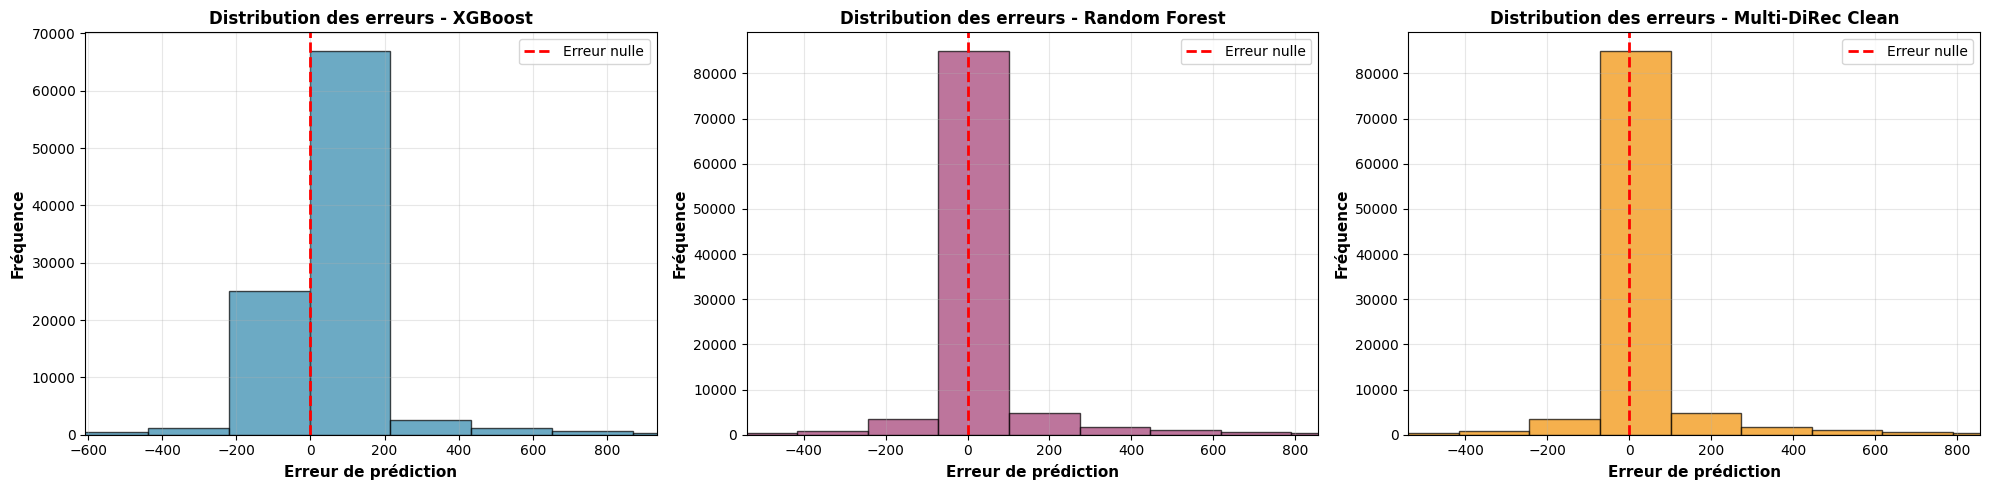

In [15]:
# Calcul des erreurs
pred_test_xgb['error'] = pred_test_xgb['y_pred'] - pred_test_xgb['y_true']
pred_test_rf['error'] = pred_test_rf['y_pred'] - pred_test_rf['y_true']
pred_test_result_multi_direc_clean['error'] = pred_test_result_multi_direc_clean['y_pred'] - pred_test_result_multi_direc_clean['y_true']

# Calculer les percentiles pour limiter les outliers
xgb_limits = pred_test_xgb['error'].quantile([0.01, 0.99])
rf_limits = pred_test_rf['error'].quantile([0.01, 0.99])
multi_direc_limits = pred_test_result_multi_direc_clean['error'].quantile([0.01, 0.99])

# Visualisation avec 3 graphiques
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# XGBoost
axes[0].hist(pred_test_xgb['error'], bins=100, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[0].set_xlabel('Erreur de prédiction', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution des erreurs - XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlim(xgb_limits[0.01], xgb_limits[0.99])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].hist(pred_test_rf['error'], bins=100, color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[1].set_xlabel('Erreur de prédiction', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution des erreurs - Random Forest', fontsize=12, fontweight='bold')
axes[1].set_xlim(rf_limits[0.01], rf_limits[0.99])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Multi-DiRec Clean
axes[2].hist(pred_test_result_multi_direc_clean['error'], bins=100, color='#F18F01', alpha=0.7, edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[2].set_xlabel('Erreur de prédiction', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[2].set_title('Distribution des erreurs - Multi-DiRec Clean', fontsize=12, fontweight='bold')
axes[2].set_xlim(multi_direc_limits[0.01], multi_direc_limits[0.99])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Prédictions vs Valeurs réelles

Nuage de points comparant les prédictions aux valeurs observées.

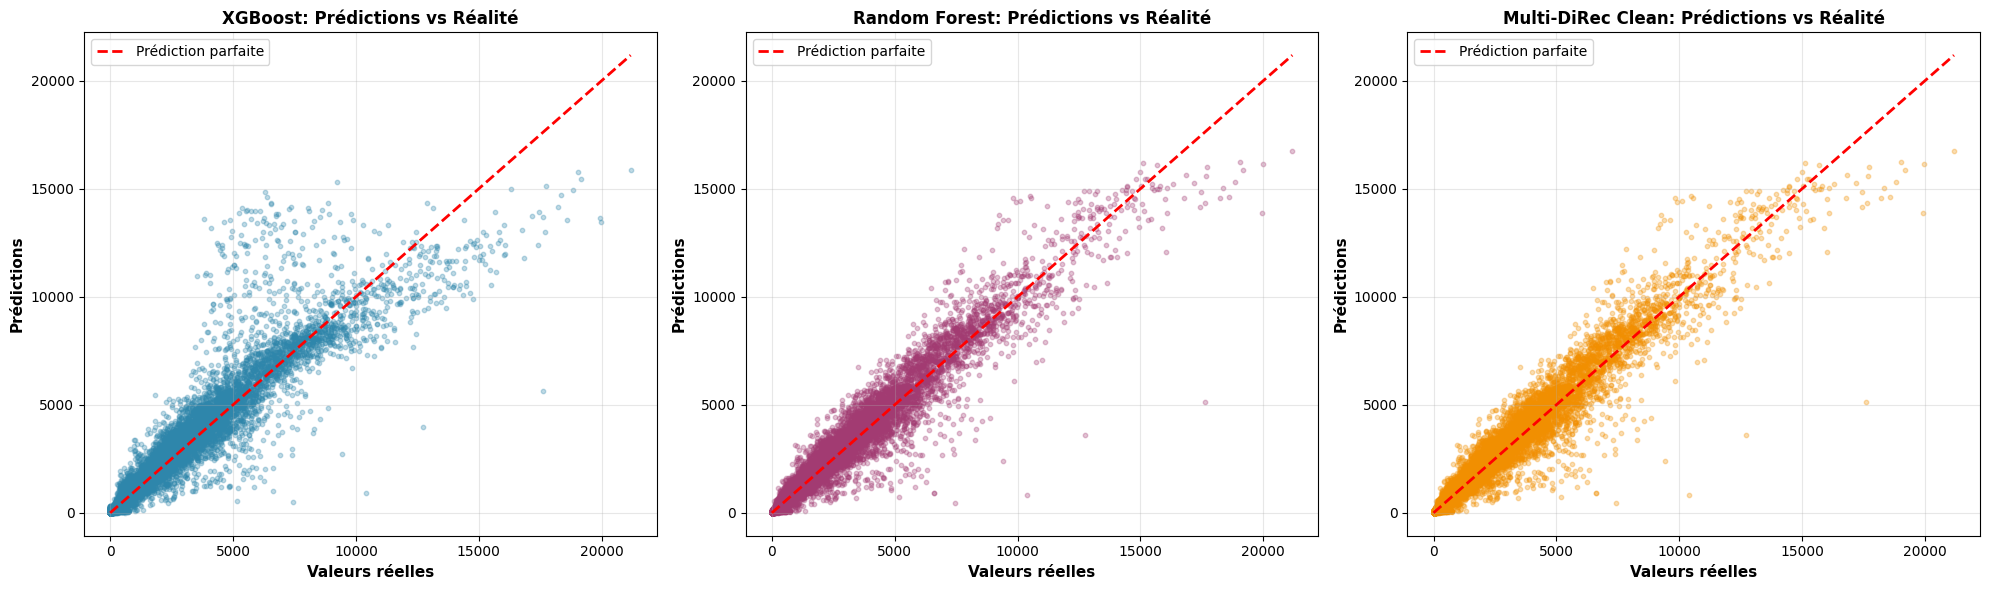

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# XGBoost
axes[0].scatter(pred_test_xgb['y_true'], pred_test_xgb['y_pred'], 
                alpha=0.3, s=10, color='#2E86AB')
axes[0].plot([0, pred_test_xgb['y_true'].max()], 
             [0, pred_test_xgb['y_true'].max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Prédictions', fontsize=11, fontweight='bold')
axes[0].set_title('XGBoost: Prédictions vs Réalité', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(pred_test_rf['y_true'], pred_test_rf['y_pred'], 
                alpha=0.3, s=10, color='#A23B72')
axes[1].plot([0, pred_test_rf['y_true'].max()], 
             [0, pred_test_rf['y_true'].max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[1].set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Prédictions', fontsize=11, fontweight='bold')
axes[1].set_title('Random Forest: Prédictions vs Réalité', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Multi-DiRec Clean
axes[2].scatter(pred_test_result_multi_direc_clean['y_true'], 
                pred_test_result_multi_direc_clean['y_pred'], 
                alpha=0.3, s=10, color='#F18F01')
axes[2].plot([0, pred_test_result_multi_direc_clean['y_true'].max()], 
             [0, pred_test_result_multi_direc_clean['y_true'].max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
axes[2].set_xlabel('Valeurs réelles', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Prédictions', fontsize=11, fontweight='bold')
axes[2].set_title('Multi-DiRec Clean: Prédictions vs Réalité', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.3 Erreurs moyennes par famille de produits

Identification des catégories de produits les plus difficiles à prédire.

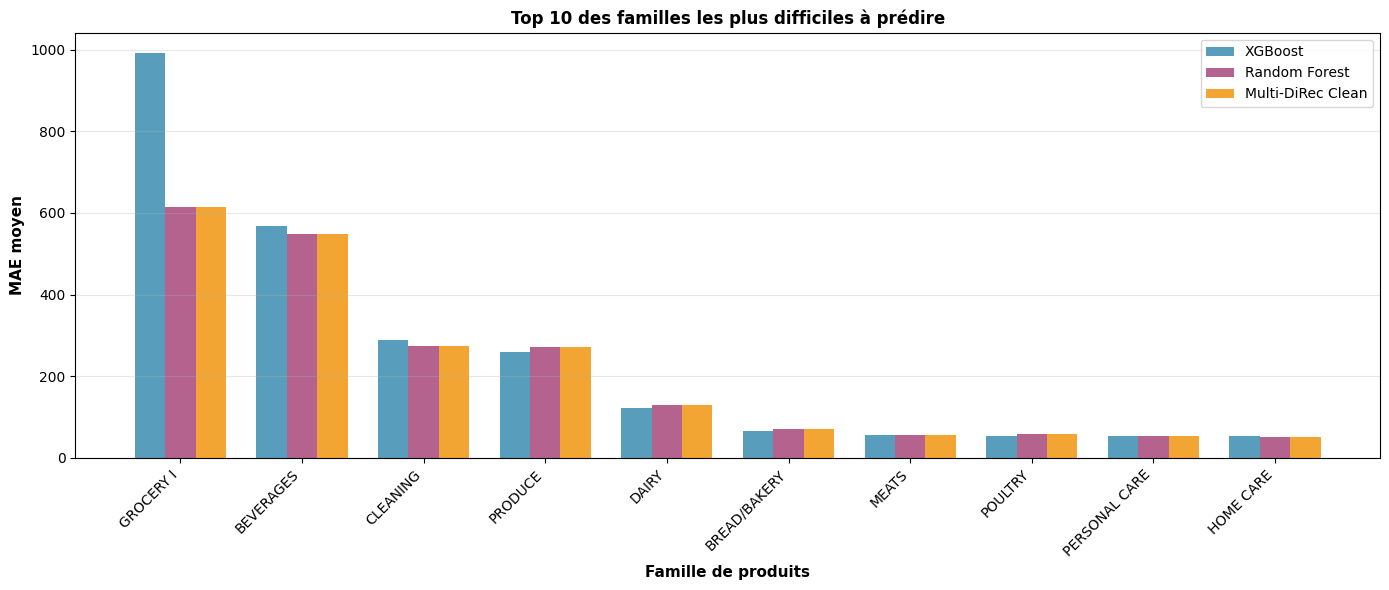

In [17]:
# Calcul des erreurs absolues moyennes par famille
mae_by_family_xgb = pred_test_xgb.groupby('family').apply(
    lambda x: np.abs(x['y_pred'] - x['y_true']).mean()
).sort_values(ascending=False)

mae_by_family_rf = pred_test_rf.groupby('family').apply(
    lambda x: np.abs(x['y_pred'] - x['y_true']).mean()
).sort_values(ascending=False)

mae_by_family_multi_direc = pred_test_result_multi_direc_clean.groupby('family').apply(
    lambda x: np.abs(x['y_pred'] - x['y_true']).mean()
).sort_values(ascending=False)

# Top 10 des familles les plus difficiles (basé sur XGBoost)
top_families = mae_by_family_xgb.head(10).index

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top_families))
width = 0.25

ax.bar(x - width, mae_by_family_xgb[top_families], width, 
       label='XGBoost', color='#2E86AB', alpha=0.8)
ax.bar(x, mae_by_family_rf[top_families], width, 
       label='Random Forest', color='#A23B72', alpha=0.8)
ax.bar(x + width, mae_by_family_multi_direc[top_families], width, 
       label='Multi-DiRec Clean', color='#F18F01', alpha=0.8)

ax.set_xlabel('Famille de produits', fontsize=11, fontweight='bold')
ax.set_ylabel('MAE moyen', fontsize=11, fontweight='bold')
ax.set_title('Top 10 des familles les plus difficiles à prédire', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_families, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.4 Évolution temporelle des prédictions

Suivi des prédictions agrégées sur la période de validation.

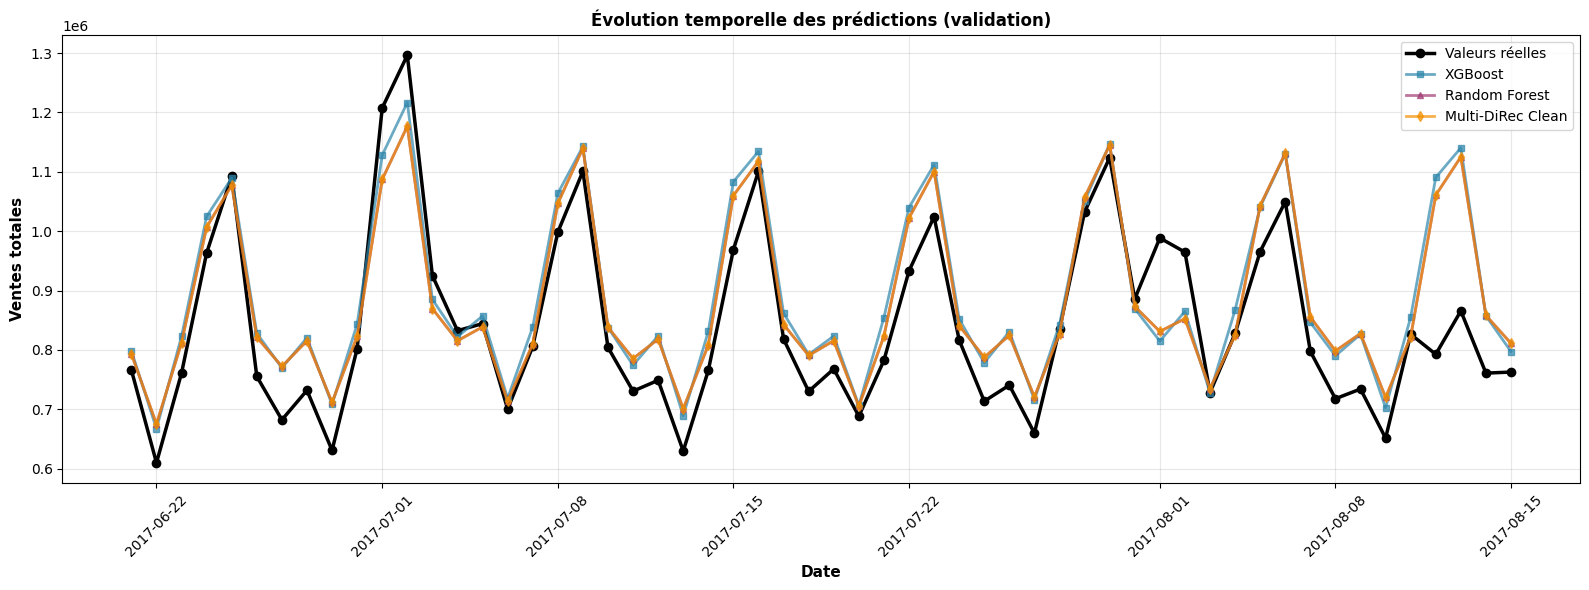

In [18]:
# Agrégation par date
daily_xgb = pred_test_xgb.groupby('date').agg({
    'y_true': 'sum',
    'y_pred': 'sum'
}).reset_index()

daily_rf = pred_test_rf.groupby('date').agg({
    'y_true': 'sum',
    'y_pred': 'sum'
}).reset_index()

daily_multi_direc = pred_test_result_multi_direc_clean.groupby('date').agg({
    'y_true': 'sum',
    'y_pred': 'sum'
}).reset_index()

# Visualisation
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily_xgb['date'], daily_xgb['y_true'], 
        label='Valeurs réelles', color='black', linewidth=2.5, marker='o', markersize=6)
ax.plot(daily_xgb['date'], daily_xgb['y_pred'], 
        label='XGBoost', color='#2E86AB', linewidth=2, marker='s', markersize=5, alpha=0.7)
ax.plot(daily_rf['date'], daily_rf['y_pred'], 
        label='Random Forest', color='#A23B72', linewidth=2, marker='^', markersize=5, alpha=0.7)
ax.plot(daily_multi_direc['date'], daily_multi_direc['y_pred'], 
        label='Multi-DiRec Clean', color='#F18F01', linewidth=2, marker='d', markersize=5, alpha=0.7)

ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventes totales', fontsize=11, fontweight='bold')
ax.set_title('Évolution temporelle des prédictions (validation)', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 7.5 Erreurs par magasin

Performance des modèles selon les différents points de vente.

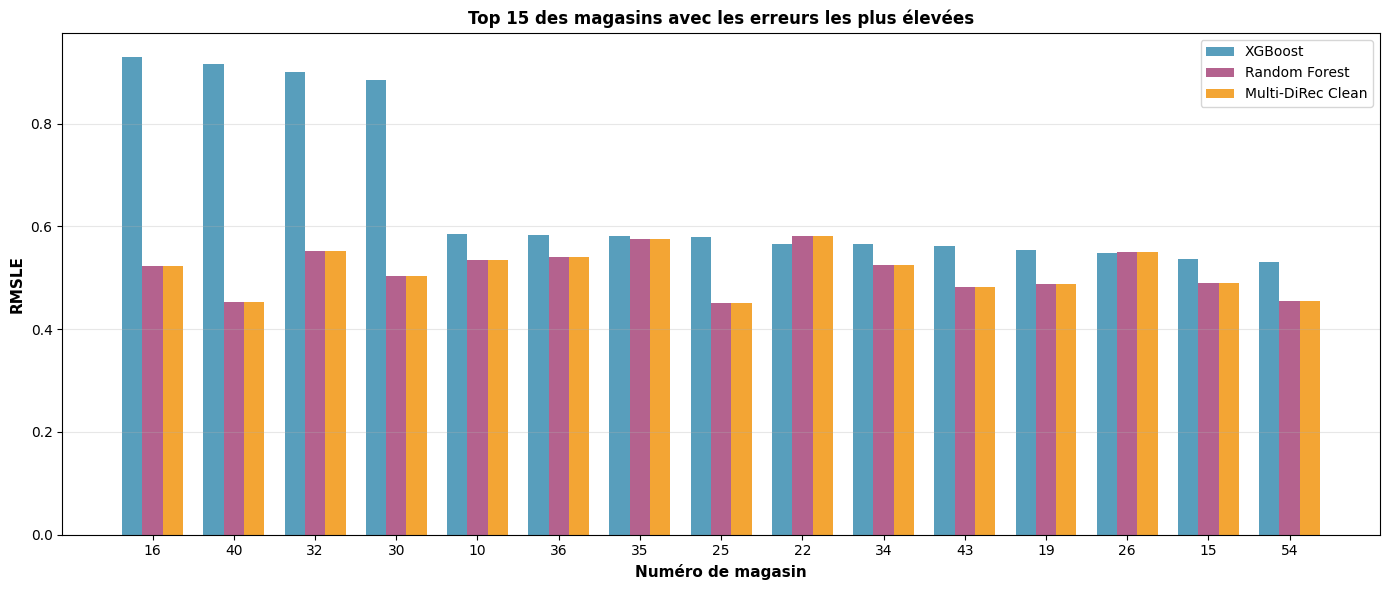

In [19]:
# Calcul du RMSLE par magasin
from sklearn.metrics import mean_squared_log_error

rmsle_by_store_xgb = pred_test_xgb.groupby('store_nbr').apply(
    lambda x: np.sqrt(mean_squared_log_error(x['y_true'], x['y_pred']))
).sort_values(ascending=False)

rmsle_by_store_rf = pred_test_rf.groupby('store_nbr').apply(
    lambda x: np.sqrt(mean_squared_log_error(x['y_true'], x['y_pred']))
).sort_values(ascending=False)

rmsle_by_store_multi_direc = pred_test_result_multi_direc_clean.groupby('store_nbr').apply(
    lambda x: np.sqrt(mean_squared_log_error(x['y_true'], x['y_pred']))
).sort_values(ascending=False)

# Top 15 magasins avec plus d'erreurs
top_stores = rmsle_by_store_xgb.head(15).index

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top_stores))
width = 0.25

ax.bar(x - width, rmsle_by_store_xgb[top_stores], width, 
       label='XGBoost', color='#2E86AB', alpha=0.8)
ax.bar(x, rmsle_by_store_rf[top_stores], width, 
       label='Random Forest', color='#A23B72', alpha=0.8)
ax.bar(x + width, rmsle_by_store_multi_direc[top_stores], width, 
       label='Multi-DiRec Clean', color='#F18F01', alpha=0.8)

ax.set_xlabel('Numéro de magasin', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSLE', fontsize=11, fontweight='bold')
ax.set_title('Top 15 des magasins avec les erreurs les plus élevées', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_stores)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.6 Boxplot des erreurs relatives

Distribution des erreurs en pourcentage des valeurs réelles.

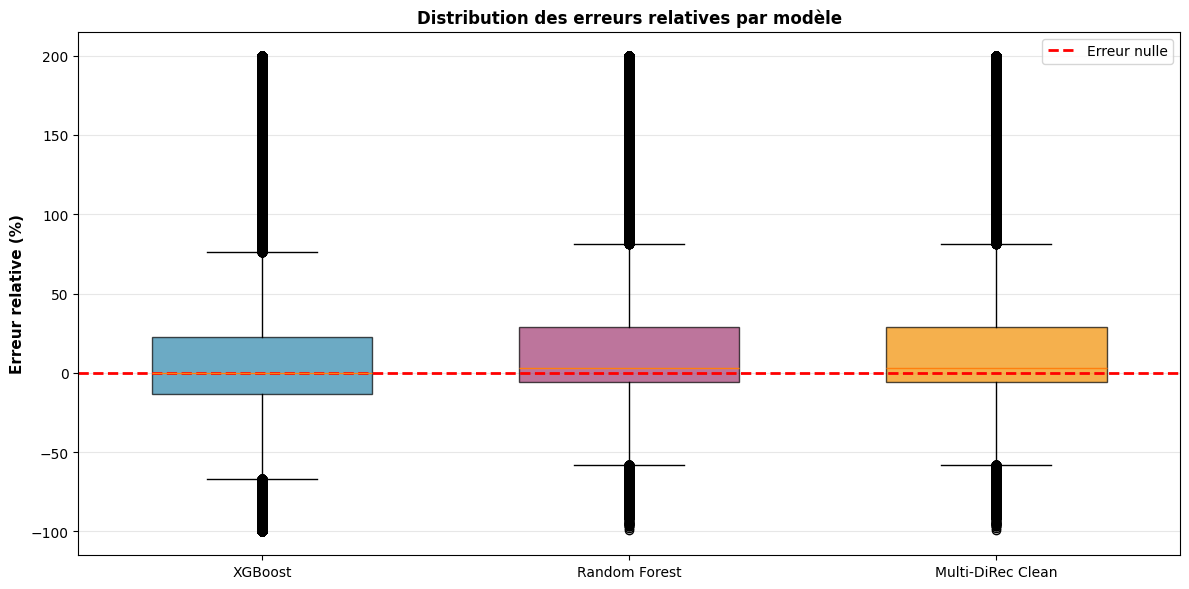

In [20]:
# Calcul des erreurs relatives (en %)
pred_test_xgb['error_pct'] = np.where(
    pred_test_xgb['y_true'] > 0,
    100 * (pred_test_xgb['y_pred'] - pred_test_xgb['y_true']) / pred_test_xgb['y_true'],
    0
)

pred_test_rf['error_pct'] = np.where(
    pred_test_rf['y_true'] > 0,
    100 * (pred_test_rf['y_pred'] - pred_test_rf['y_true']) / pred_test_rf['y_true'],
    0
)

pred_test_result_multi_direc_clean['error_pct'] = np.where(
    pred_test_result_multi_direc_clean['y_true'] > 0,
    100 * (pred_test_result_multi_direc_clean['y_pred'] - pred_test_result_multi_direc_clean['y_true']) / pred_test_result_multi_direc_clean['y_true'],
    0
)

# Limitation des erreurs extrêmes pour une meilleure visualisation
errors_xgb = pred_test_xgb['error_pct'].clip(-200, 200)
errors_rf = pred_test_rf['error_pct'].clip(-200, 200)
errors_multi_direc = pred_test_result_multi_direc_clean['error_pct'].clip(-200, 200)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot([errors_xgb, errors_rf, errors_multi_direc], 
                 labels=['XGBoost', 'Random Forest', 'Multi-DiRec Clean'],
                 patch_artist=True,
                 widths=0.6)

# Couleurs
colors = ['#2E86AB', '#A23B72', '#F18F01']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
ax.set_ylabel('Erreur relative (%)', fontsize=11, fontweight='bold')
ax.set_title('Distribution des erreurs relatives par modèle', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 7.7 Exemple détaillé sur un magasin/famille spécifique

Zoom sur le couple magasin-famille avec le plus gros volume de ventes.

Analyse détaillée pour:
  Magasin: 45
  Famille: GROCERY I
  Ventes totales: 638,471


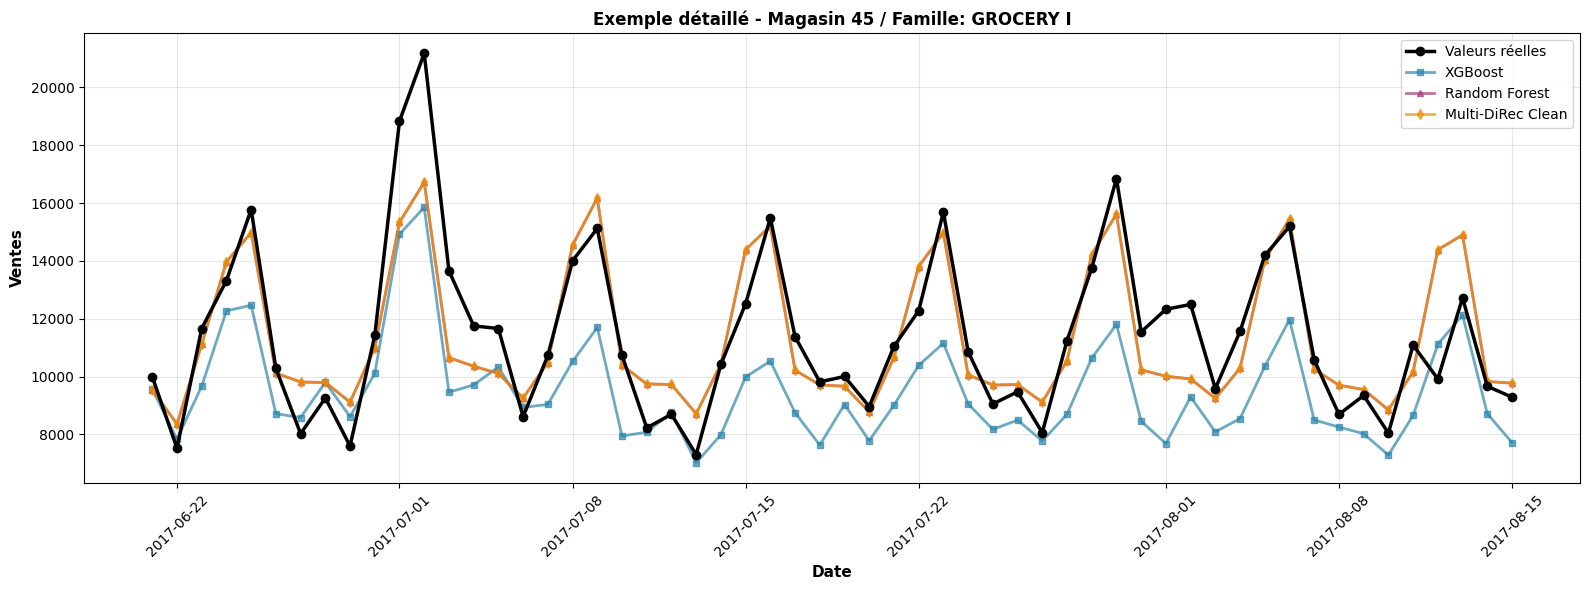

In [21]:
# Identification du couple store/family avec le plus de ventes
store_family_sales = pred_test_xgb.groupby(['store_nbr', 'family'])['y_true'].sum().sort_values(ascending=False)
top_store, top_family = store_family_sales.index[0]

print(f"Analyse détaillée pour:")
print(f"  Magasin: {top_store}")
print(f"  Famille: {top_family}")
print(f"  Ventes totales: {store_family_sales.iloc[0]:,.0f}")

# Extraction des données
pred_xgb_detail = pred_test_xgb[
    (pred_test_xgb['store_nbr'] == top_store) & 
    (pred_test_xgb['family'] == top_family)
].sort_values('date')

pred_rf_detail = pred_test_rf[
    (pred_test_rf['store_nbr'] == top_store) & 
    (pred_test_rf['family'] == top_family)
].sort_values('date')

pred_multi_direc_detail = pred_test_result_multi_direc_clean[
    (pred_test_result_multi_direc_clean['store_nbr'] == top_store) & 
    (pred_test_result_multi_direc_clean['family'] == top_family)
].sort_values('date')

# Visualisation
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(pred_xgb_detail['date'], pred_xgb_detail['y_true'], 
        label='Valeurs réelles', color='black', linewidth=2.5, 
        marker='o', markersize=6, zorder=3)
ax.plot(pred_xgb_detail['date'], pred_xgb_detail['y_pred'], 
        label='XGBoost', color='#2E86AB', linewidth=2, 
        marker='s', markersize=5, alpha=0.7)
ax.plot(pred_rf_detail['date'], pred_rf_detail['y_pred'], 
        label='Random Forest', color='#A23B72', linewidth=2, 
        marker='^', markersize=5, alpha=0.7)
ax.plot(pred_multi_direc_detail['date'], pred_multi_direc_detail['y_pred'], 
        label='Multi-DiRec Clean', color='#F18F01', linewidth=2, 
        marker='d', markersize=5, alpha=0.7)

ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.set_ylabel('Ventes', fontsize=11, fontweight='bold')
ax.set_title(f'Exemple détaillé - Magasin {top_store} / Famille: {top_family}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Conclusion

Ce notebook a permis de comparer XGBoost et Random Forest, ainsi que différentes combinaisons de ces deux modèles pour la prédiction de séries temporelles de ventes.

**Points clés**:
- Approche récursive permettant d'utiliser les prédictions précédentes comme features
- Encodages optimisés calculés une seule fois
- Split temporel respectant la structure des séries temporelles
- Exclusion des variables oil_price pour éviter le data leakage